In [1]:
import numpy as np
import scipy.constants as const
import matplotlib.pyplot as plt
# plt.style.use('sci.mplstyle')

In [ ]:
def phuongphap_secant(tol, p0, p1, N, filename, hamso):
    with open(f"{filename}_{hamso.__name__}_{tol}_secant.txt", "w", encoding="utf-8") as file:
        file.write(f"# Giai phuong trinh f(x) = 0 bang phuong phap Secant\n")
        file.write(f"# Do chinh xac cua phep tinh la: {tol}\n")
        file.write(f"#" * 110 + "\n") 
        
        file.write(f"{'i':>3s}  {'p':>25s}  {'f(p)':>25s}  {'Sai so':>25s}\n")
        
        for i in range(0, N):
            # Tính mẫu số trước để tránh lỗi chia cho 0
            mau_so = hamso(p1) - hamso(p0)
            if mau_so == 0:
                file.write(f"!\n f(p1) bang f(p0). Phep chia cho 0, thuat toan dung lai.\n")
                break
                
            p = p1 - (hamso(p1) * (p1 - p0)) / mau_so
            
            # Tính sai số
            sai_so = abs(p - p1)
            
            file.write(f"{i:3d}  {p:25.16f}  {hamso(p):25.16e}  {sai_so:25.16e}\n")
            
            # Kiểm tra sai số
            if sai_so < tol:
                break
                
            p0 = p1
            p1 = p
            
            if i == N - 1:
                file.write("!" * 70 + "\n" +"!" * 70 + "\n")
                file.write(f"!\n Khong tim duoc nghiem sau {N} vong lap\n")

In [3]:
def print_thongso_gieng(a, V_0):
    z_0 = a * np.sqrt(V_0*0.0483)   # De cho 2m/hbar^2 = 0.0483 MeV^-1 fm^-2
    print(f"a = {a:.3f} fm")
    print(f"V_0 = {V_0:.3f} MeV")
    print(f"z_0 = {z_0:.8f}")

# TH1: hẹp & nông
V_MeV_hep_nong = 1.0
a_fm_hep_nong = 2

print("THE HEP & NONG")
print_thongso_gieng(a_fm_hep_nong, V_MeV_hep_nong)

print()

# TH2: rộng & sâu
V_MeV_rong_sau = 10.0
a_fm_rong_sau = 10.0

print("THE RONG & SAU")
print_thongso_gieng(a_fm_rong_sau, V_MeV_rong_sau)

THE HEP & NONG
a = 2.000 fm
V_0 = 1.000 MeV
z_0 = 0.43954522

THE RONG & SAU
a = 10.000 fm
V_0 = 10.000 MeV
z_0 = 6.94982014


In [4]:
def vehinh(z_0,N,title):
    z = np.linspace(0, 8, 10000)

    y1 = np.sqrt((z_0/z)**2 - 1)
    y2 = np.tan(z)

    y2[np.abs(y2) > 15] = np.nan

    plt.figure(figsize=(10, 6))

    plt.plot(z, y1, label=r'$\sqrt{(z_0/z)^2-1}$', color='C0')
    plt.plot(z, y2, label=r'$\tan z$', color='C1')

    x_ticks = np.arange(np.pi/2, 20 + np.pi/2, np.pi/2)

    x_labels = []
    for i in range(1, len(x_ticks) + 1):
        if i == 1:
            x_labels.append(r'$\frac{\pi}{2}$')
        else:
            x_labels.append(rf'$\frac{{{i}\pi}}{{2}}$')

    plt.xticks(x_ticks, x_labels)

    for xt in x_ticks:
        plt.axvline(xt, color='gray', lw=0.5, ls='--')

    plt.axhline(0, color='gray', lw=0.5, ls='--')

    #plt.axvline(3/8*np.pi, color='gray', lw=0.5, ls='--')

    #plt.axvline(0.9*np.pi/2, color='gray', lw=0.5, ls='--')

    #plt.axvline((2+1/16)*np.pi, color='red', lw=0.5, ls='--')

    #plt.axvline((2+1/8)*np.pi, color='red', lw=0.5, ls='--')

    plt.xlim(0, 10)

    x_lim = N * np.pi / 2
    plt.xlim(0, x_lim)
    plt.ylim(0, 10)
    plt.xlabel('z')
    plt.title(rf'$z_0={z_0:.8f}$'+f' - {title}')
    plt.legend()
    plt.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32492\1586281576.py:4: RuntimeWarning: divide by zero encountered in divide
  y1 = np.sqrt((z_0/z)**2 - 1)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32492\1586281576.py:4: RuntimeWarning: invalid value encountered in sqrt
  y1 = np.sqrt((z_0/z)**2 - 1)


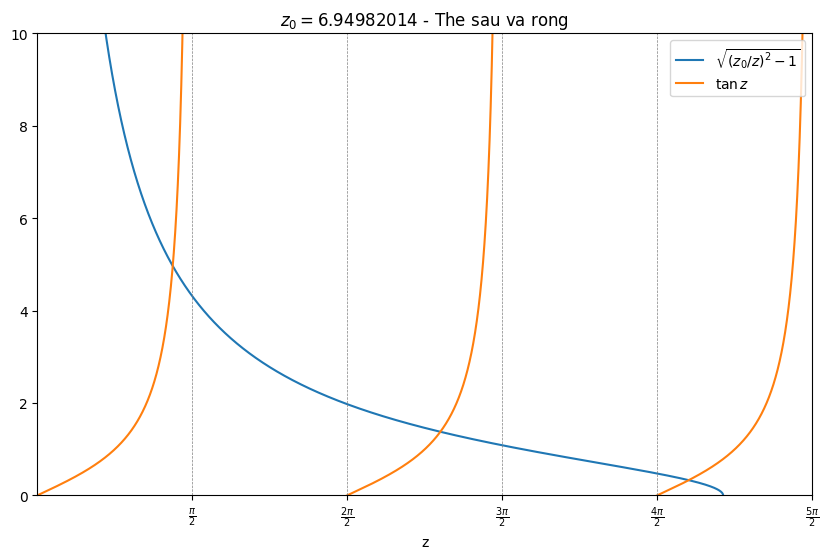

In [5]:
vehinh(6.94982014,5, 'The sau va rong')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32492\1586281576.py:4: RuntimeWarning: divide by zero encountered in divide
  y1 = np.sqrt((z_0/z)**2 - 1)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32492\1586281576.py:4: RuntimeWarning: invalid value encountered in sqrt
  y1 = np.sqrt((z_0/z)**2 - 1)


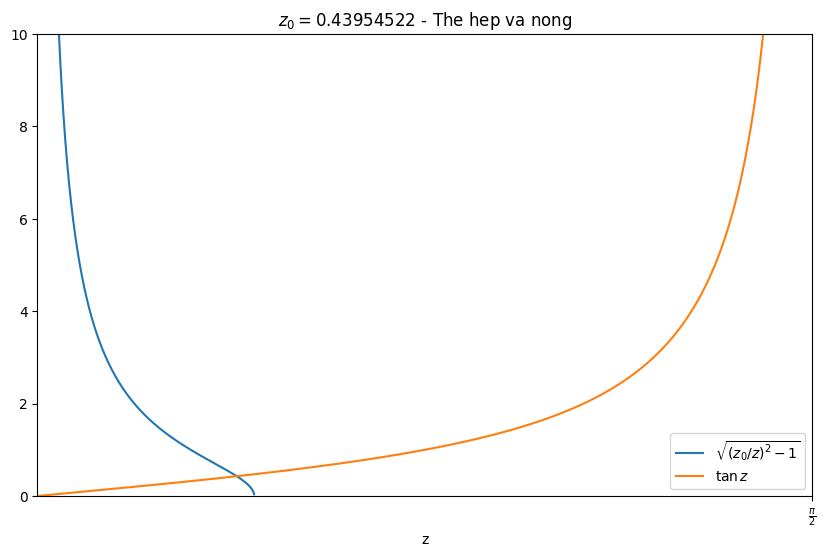

In [6]:
vehinh(0.43954522,1, 'The hep va nong')

In [7]:
def giengthehuuhan(a, V_0, z):
    z_0 = a * np.sqrt(V_0*0.0483)   # De cho 2m/hbar^2 = 0.0483 MeV^-1 fm^-2
    y1 = np.sqrt((z_0/z)**2 - 1)
    y2 = np.tan(z)
    pt_tim_z = y1 - y2
    return z_0, pt_tim_z




# Doi voi phuong phap scant chung ta se chon 2 diem gan nhau de tim nghiem, do do ta se chon p0 va p1 gan nhau

p0_sau_rong = [3/8*np.pi,
               5/4*np.pi,
               (2+1/16)*np.pi]
p1_sau_rong = [0.9*np.pi/2,
               0.9*3*np.pi/2,
               (2+1/8)*np.pi]

# Doi voi gieng hep va nong thi se co 1 nghiem
du_doan_nghiem_nong_hep = [0.1*np.pi]
# Tuy nhien doi voi nghiem nong va hep thi doan xung quanh pi/4 co the qua rong, do do ta se chon p0 va p1 gan nhau hon
p0_nong_hep = np.array([du_doan - 0.1 for du_doan in du_doan_nghiem_nong_hep])
p1_nong_hep = np.array([du_doan + 0.1 for du_doan in du_doan_nghiem_nong_hep])

In [8]:
N = 100
tol = 1e-8

def hamso_secant_sau_rong(z):
    return giengthehuuhan(a_fm_rong_sau, V_MeV_rong_sau, z)[1]

def hamso_secant_nong_hep(z):
    return giengthehuuhan(a_fm_hep_nong, V_MeV_hep_nong, z)[1]

for i in range(len(p0_sau_rong)):
    phuongphap_secant(tol, p0_sau_rong[i], p1_sau_rong[i], N, f'ketqua_sau_rong_nghiem_so_{i+1}', hamso_secant_sau_rong)

for i in range(len(du_doan_nghiem_nong_hep)):
    phuongphap_secant(tol, p0_nong_hep[i], p1_nong_hep[i], N, f'ketqua_nong_hep_nghiem_so_{i+1}', hamso_secant_nong_hep)

## Input nhu Thay dua ra
### V0 = 83 MeV
### a = 2 fm

In [9]:
V_MeV_Thayduara = 83
a_fm_Thayduara = 2

print("Tinh z0 ma Thay dua ra")
print_thongso_gieng(a_fm_Thayduara,V_MeV_Thayduara)

Tinh z0 ma Thay dua ra
a = 2.000 fm
V_0 = 83.000 MeV
z_0 = 4.00444753


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32492\1586281576.py:4: RuntimeWarning: divide by zero encountered in divide
  y1 = np.sqrt((z_0/z)**2 - 1)
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32492\1586281576.py:4: RuntimeWarning: invalid value encountered in sqrt
  y1 = np.sqrt((z_0/z)**2 - 1)


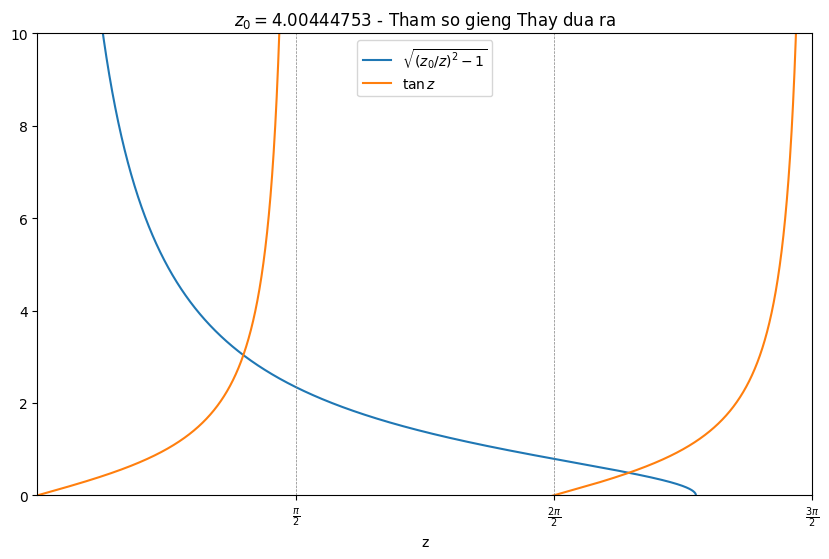

In [10]:
vehinh(4.00444753,3, 'Tham so gieng Thay dua ra')

In [11]:
p0_thayduara = [np.pi/4, np.pi/2+0.1*np.pi/2]
p1_thayduara = [0.9*np.pi/2, 5/4*np.pi]

def hamso_secant_Thay_dua_ra(z):
    return giengthehuuhan(a_fm_Thayduara, V_MeV_Thayduara, z)[1]

for i in range(len(p0_thayduara)):
    phuongphap_secant(tol, p0_thayduara[i], p1_thayduara[i], N, f'ketqua_thayduara_nghiem_so_{i+1}', hamso_secant_Thay_dua_ra)